# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [ ]:
!pip install scikit-learn==1.7.0

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 98.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [ ]:
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

In [ ]:
for col in ['TransactionDate', 'PreviousTransactionDate']:
  df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S')

df.head(5)

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2508 non-null   object        
 1   AccountID                2516 non-null   object        
 2   TransactionAmount        2511 non-null   float64       
 3   PreviousTransactionDate  2509 non-null   datetime64[ns]
 4   TransactionType          2507 non-null   object        
 5   Location                 2507 non-null   object        
 6   DeviceID                 2507 non-null   object        
 7   IP Address               2517 non-null   object        
 8   MerchantID               2514 non-null   object        
 9   Channel                  2510 non-null   object        
 10  CustomerAge              2519 non-null   float64       
 11  CustomerOccupation       2514 non-null   object        
 12  TransactionDuration      2511 non-

In [ ]:
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,NaN,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,NaN
top,TX001748,AC00362,NaN,NaN,Debit,Fort Worth,D000573,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,NaN
freq,2,12,NaN,NaN,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,NaN
mean,NaN,NaN,297.656468,2023-07-05 17:33:20.831805440,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,2024-11-04 08:09:22.576999424
min,NaN,NaN,0.260000,2023-01-02 16:00:06,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,2024-11-04 08:06:23
25%,NaN,NaN,81.310000,2023-04-03 16:14:34,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,2024-11-04 08:07:54
50%,NaN,NaN,211.360000,2023-07-07 17:40:58,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,2024-11-04 08:09:23
75%,NaN,NaN,413.105000,2023-10-06 18:44:37,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,2024-11-04 08:10:54
max,NaN,NaN,1919.110000,2024-01-01 18:21:50,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,NaN,300.000000,5.000000,14977.990000,2024-11-04 08:12:23


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

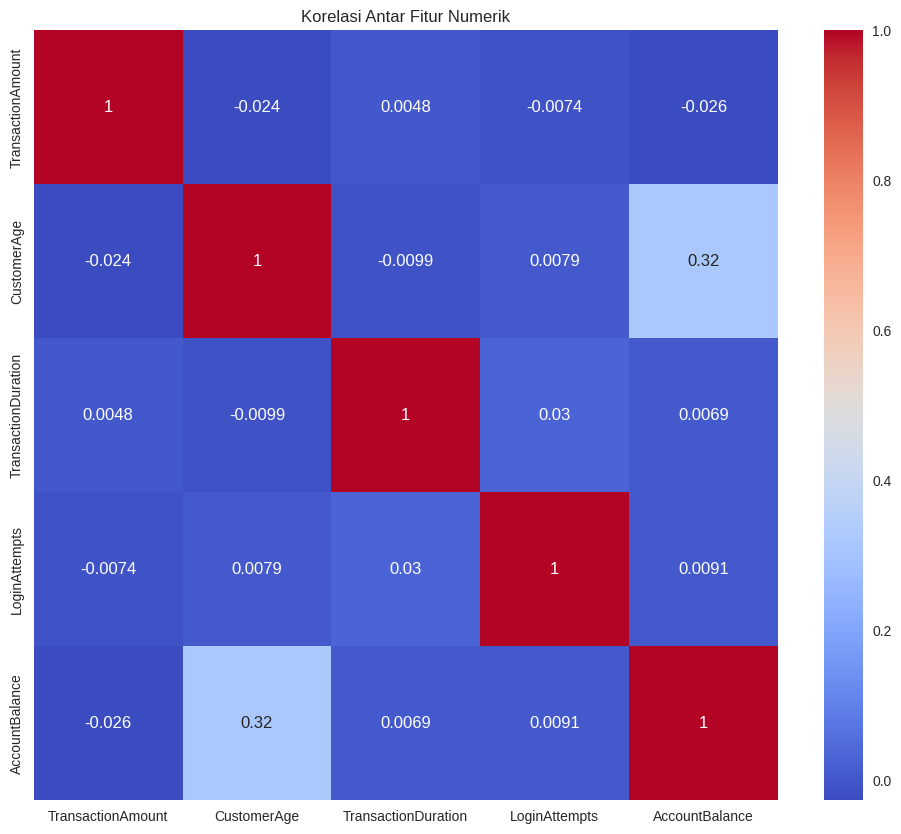

In [ ]:
correlation = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

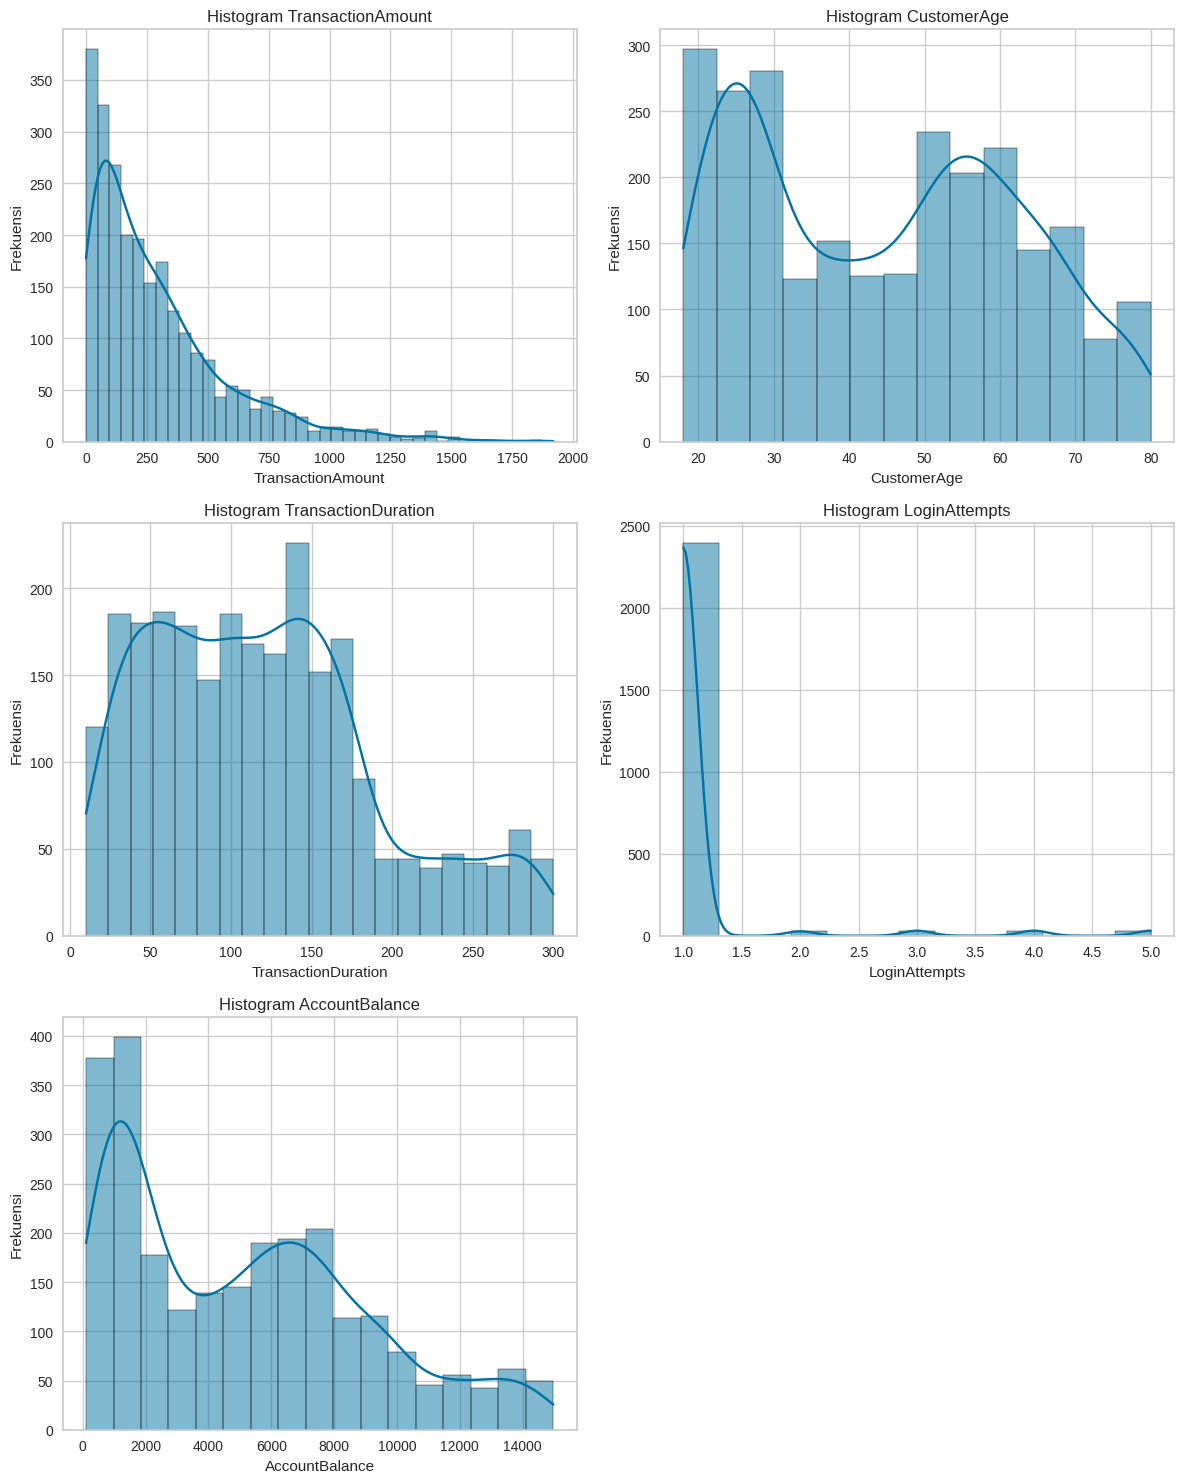

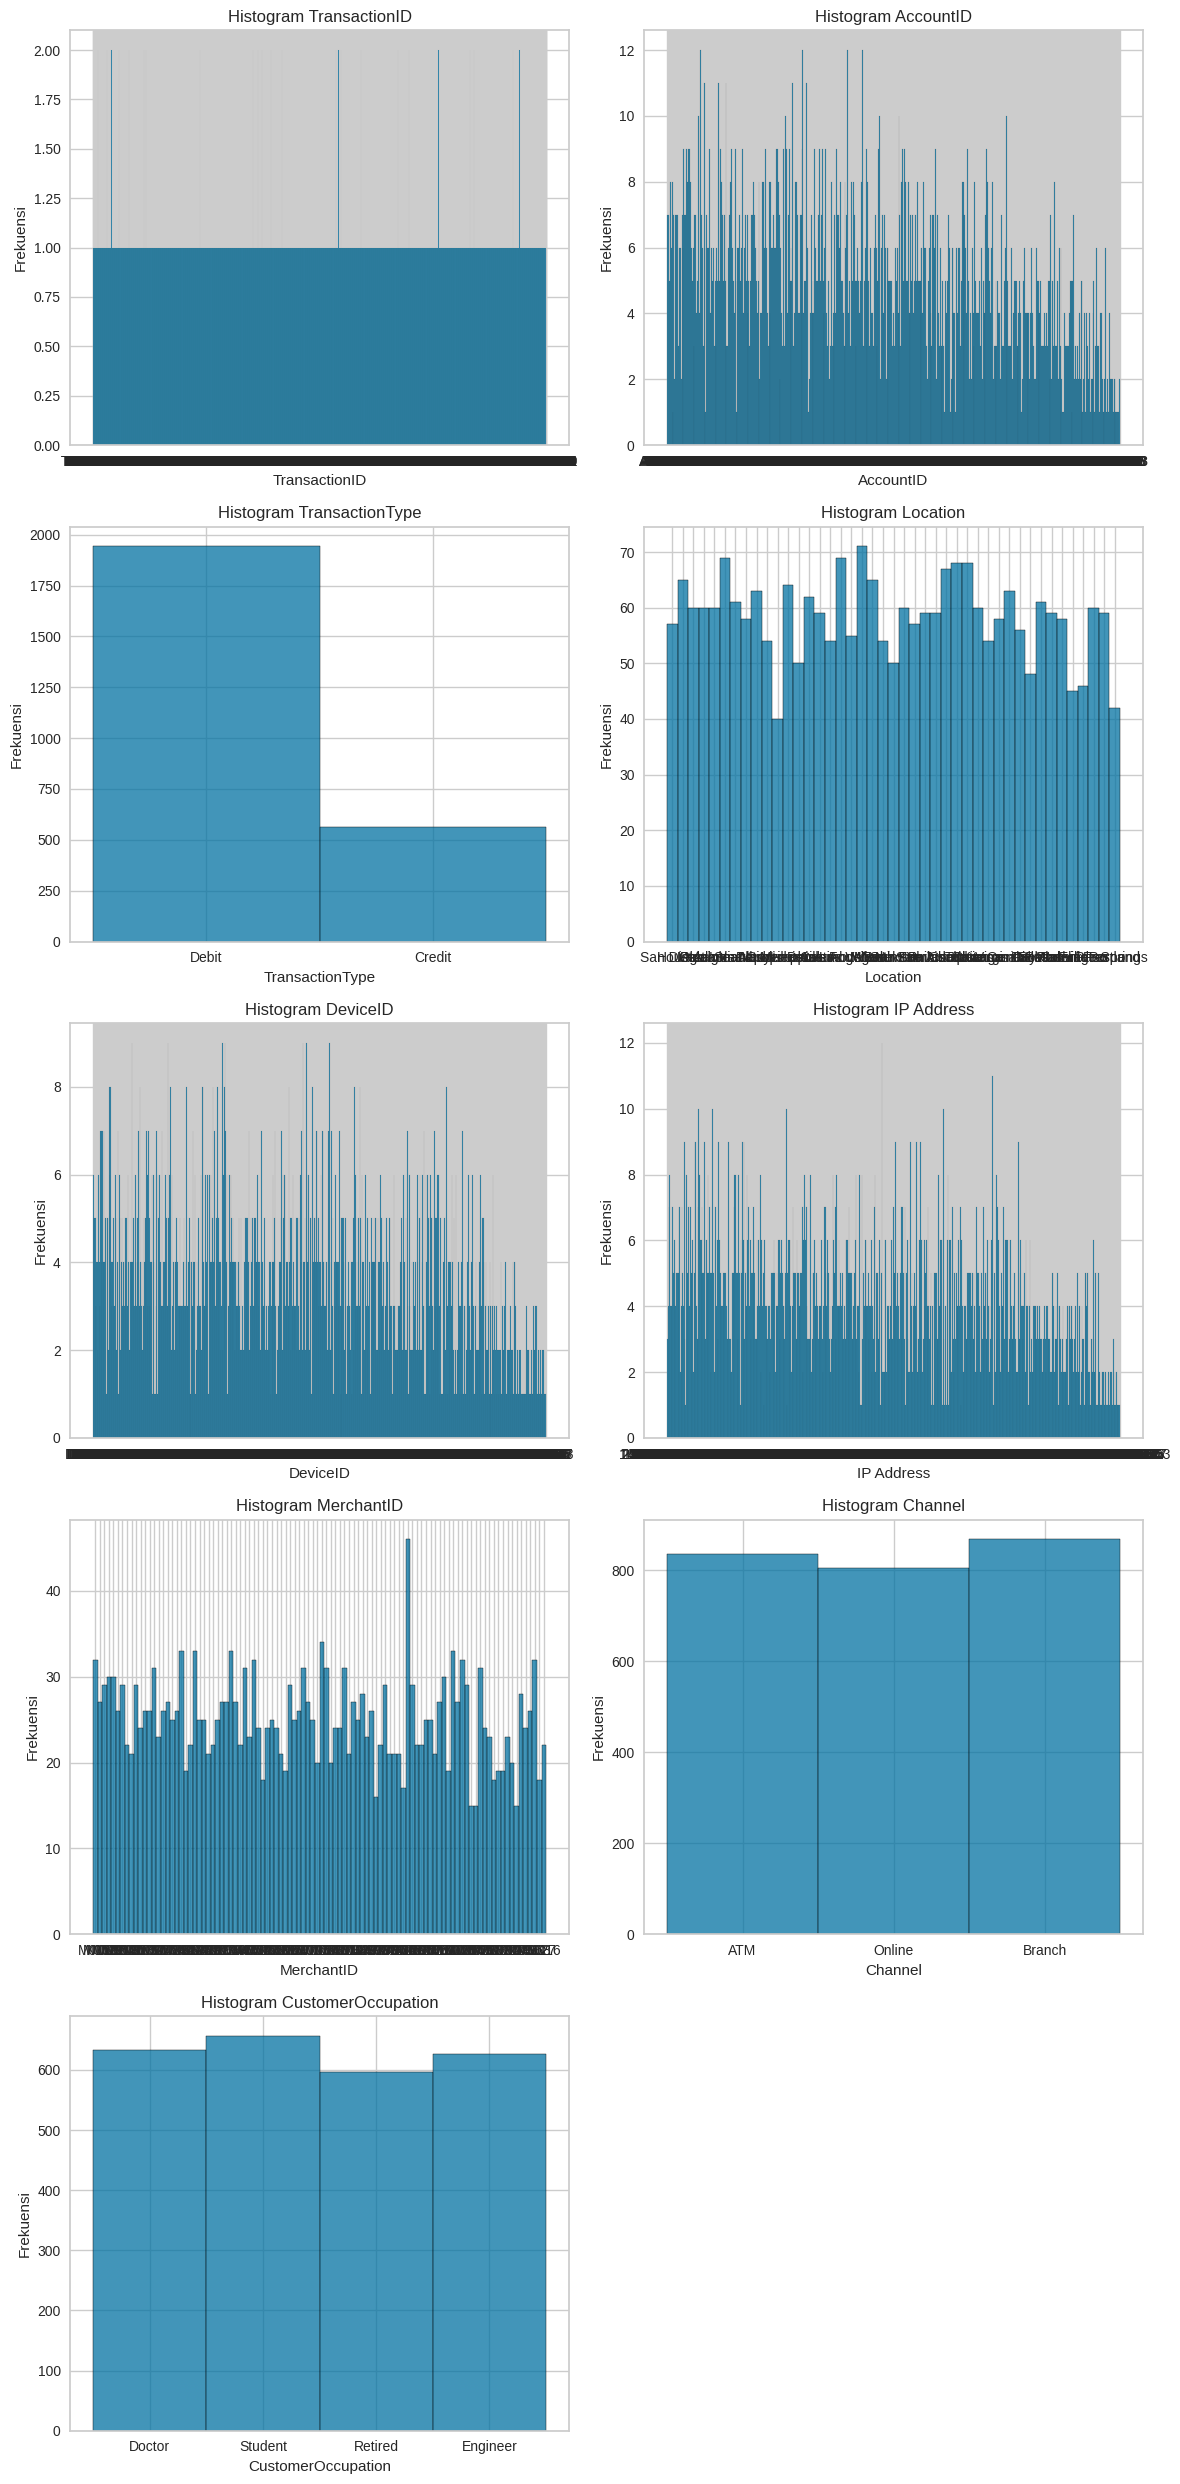

In [ ]:
# Numerical column
numerical_cols = df.select_dtypes(include='number').columns

n_cols = len(numerical_cols)
n_rows = (n_cols + 1) // 2

fig, axs = plt.subplots(n_rows, 2, figsize=(12, n_rows * 5))
axs = axs.ravel()

for idx, column in enumerate(numerical_cols):
    sns.histplot(df[column], kde=True, ax=axs[idx])
    axs[idx].set_title(f'Histogram {column}')
    axs[idx].set_xlabel(column)
    axs[idx].set_ylabel('Frekuensi')

# Sembunyikan visualisasi berlebih apabila n_cols digunakan pada plt.subplots() (opsional)
for i in range(n_cols, len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.show()

# Categorical column
categorical_cols = df.select_dtypes(include='object').columns

n_cols = len(categorical_cols)
n_rows = (n_cols + 1) // 2

fig, axs = plt.subplots(n_rows, 2, figsize=(12, n_rows * 5))
axs = axs.ravel()

for idx, column in enumerate(categorical_cols):
    sns.histplot(df[column], ax=axs[idx])
    axs[idx].set_title(f'Histogram {column}')
    axs[idx].set_xlabel(column)
    axs[idx].set_ylabel('Frekuensi')

# Sembunyikan visualisasi berlebih apabila n_cols digunakan pada plt.subplots() (opsional)
for i in range(n_cols, len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

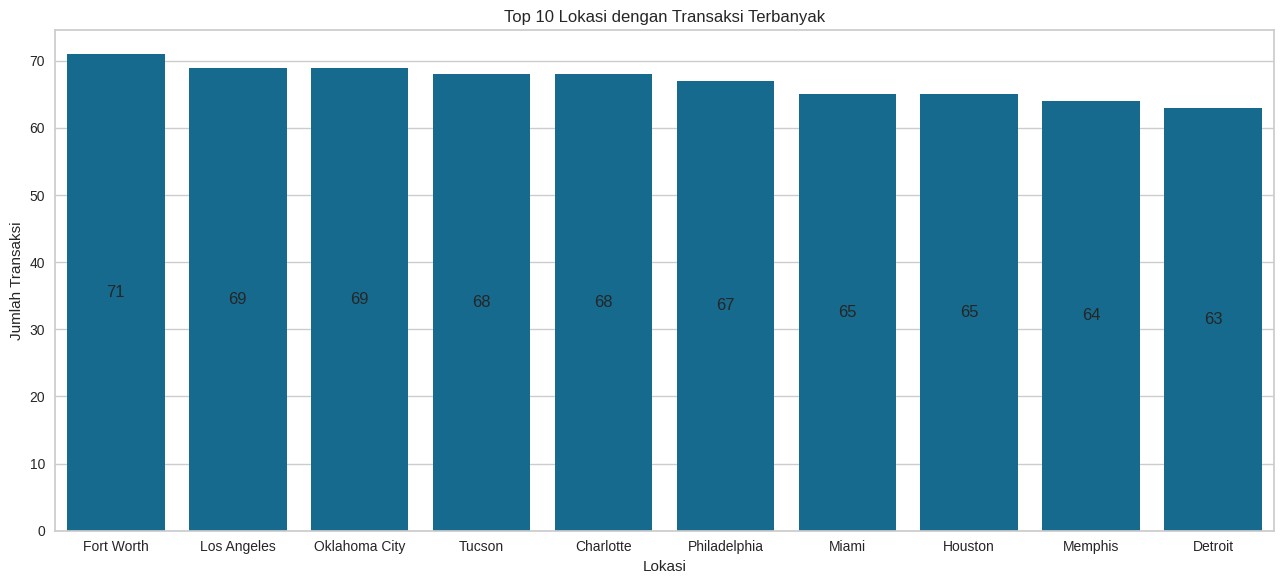

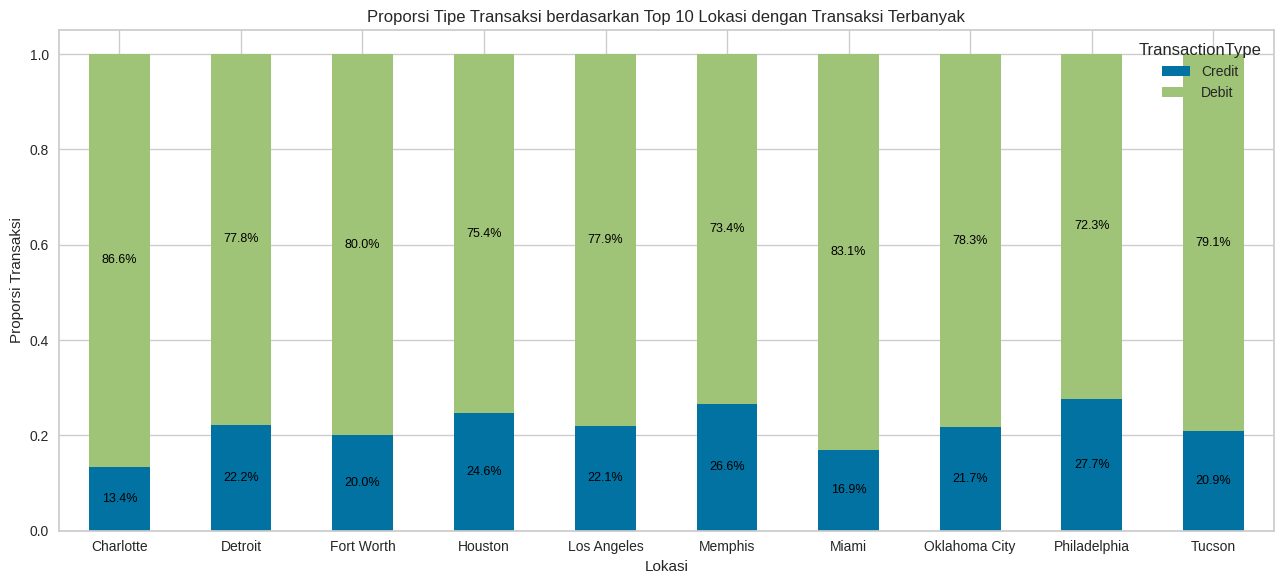

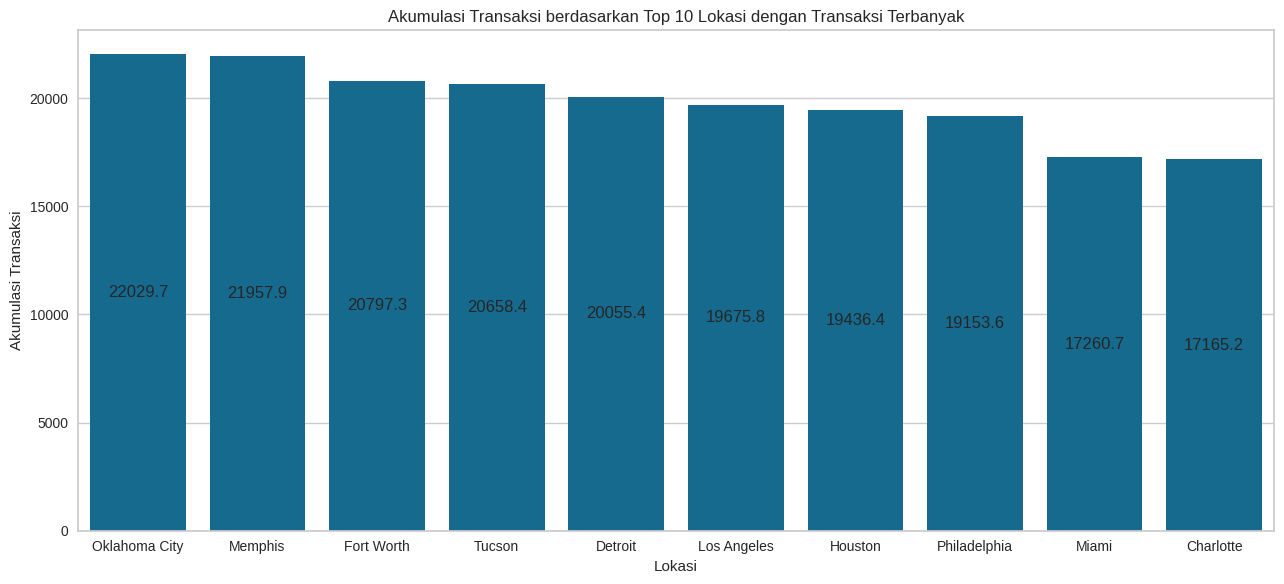

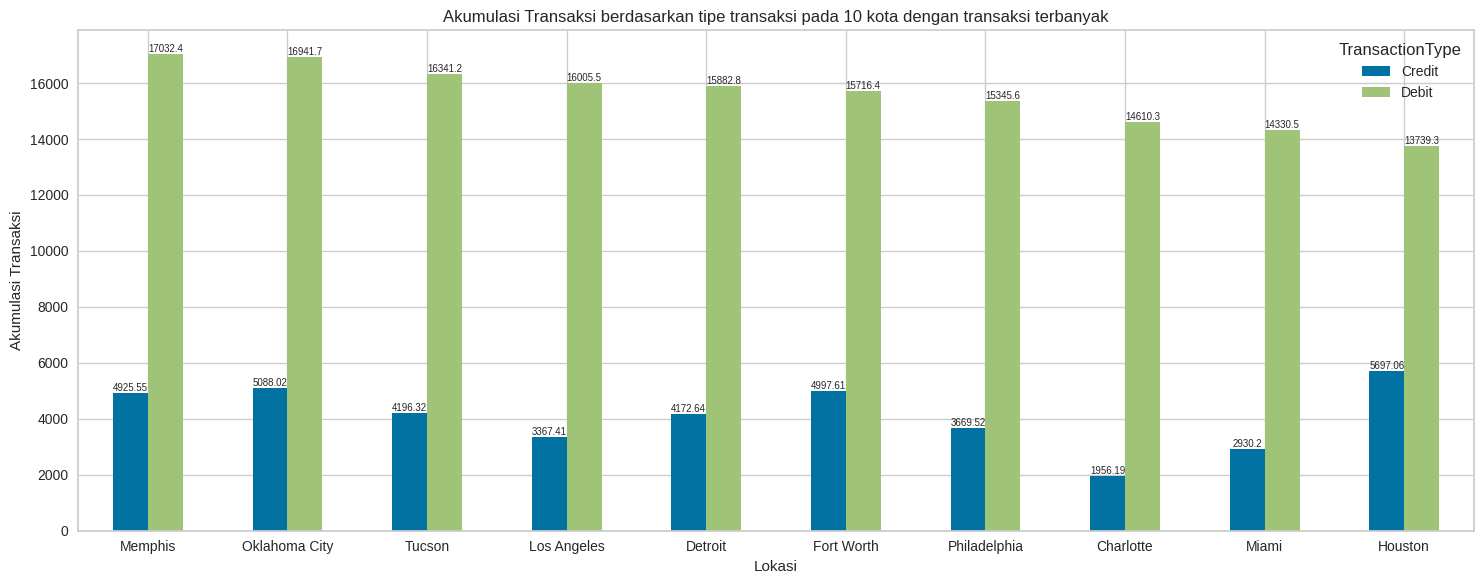

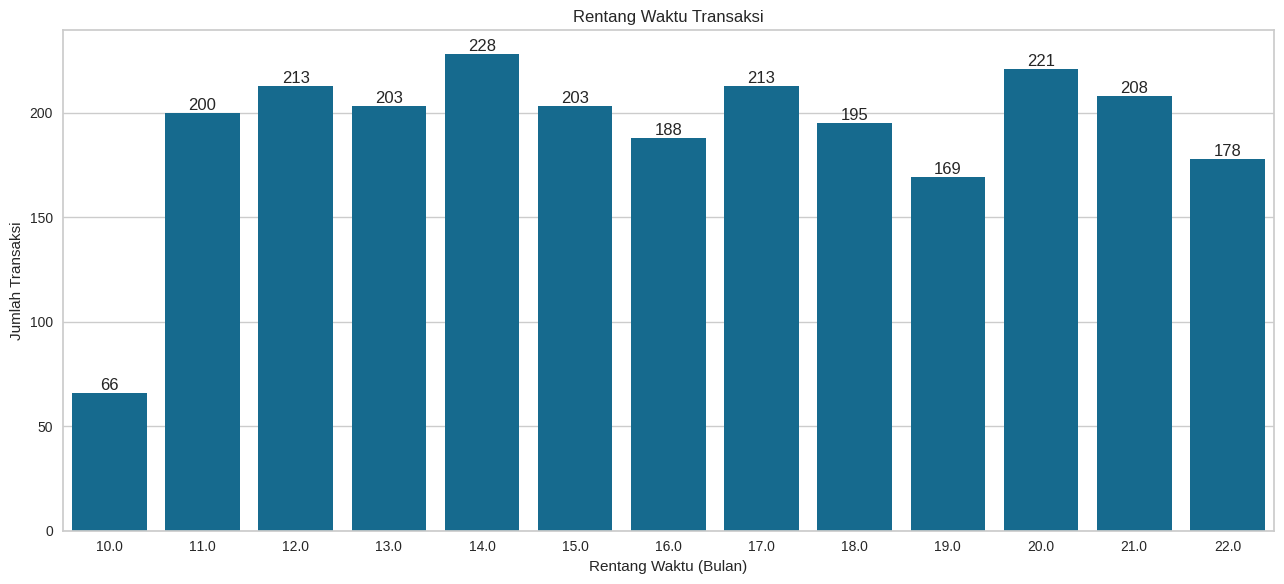

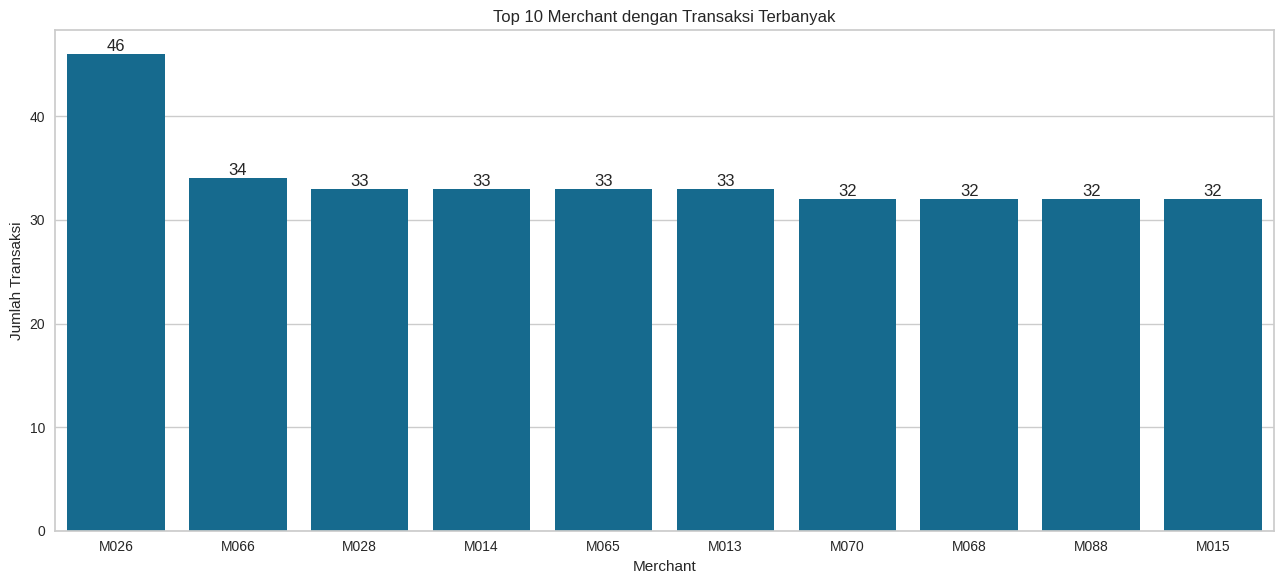

In [ ]:
# Top 10 lokasi dengan transaksi terbanyak
top_locations = df.groupby('Location').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(13, 6))
ax = sns.barplot(x=top_locations.index, y=top_locations.values)
plt.title('Top 10 Lokasi dengan Transaksi Terbanyak')
plt.xlabel('Lokasi')
plt.ylabel('Jumlah Transaksi')
plt.bar_label(ax.containers[0], label_type='center')

plt.tight_layout()
plt.show()

# Proporsi tipe transaksi berdasarkan 10 kota dengan transaksi terbanyak
top_locations = top_locations.copy()

top_10_location_transaction = df[df['Location'].isin(top_locations.index)]
location_transaction_counts = top_10_location_transaction.groupby(['Location', 'TransactionType']).size().unstack()


# Calculate proportions
location_transaction_proportions = location_transaction_counts.divide(location_transaction_counts.sum(axis=1), axis=0)

plt.figure(figsize=(13, 6))
ax = location_transaction_proportions.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Proporsi Tipe Transaksi berdasarkan Top 10 Lokasi dengan Transaksi Terbanyak')
plt.xlabel('Lokasi')
plt.ylabel('Proporsi Transaksi')
plt.xticks(rotation=360, ha='center')

# # Add labels
# for container in ax.containers:
#     labels = [f'{w:.1%}' if (w := v.get_height()) > 0 else '' for v in container]
#     ax.bar_label(container, labels=labels, label_type='center')

# Add labels
for container in ax.containers:
    for j, rect in enumerate(container.patches):
        height = rect.get_height()
        width = rect.get_width()
        x = rect.get_x()
        y = rect.get_y()
        if height > 0:
            ax.text(x + width/2., y + height/2.,
                    f'{height:.1%}',
                    ha='center', va='center',
                    color='black', fontsize=9)

plt.tight_layout()
plt.show()


# Total transaksi pada 10 kota dengan transaksi terbanyak
top_10_location_transaction = top_10_location_transaction.copy()

location_transaction_sum = top_10_location_transaction.groupby(['Location'])['TransactionAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(13, 6))
ax = sns.barplot(x=location_transaction_sum.index, y=location_transaction_sum.values)
plt.title('Akumulasi Transaksi berdasarkan Top 10 Lokasi dengan Transaksi Terbanyak')
plt.xlabel('Lokasi')
plt.ylabel('Akumulasi Transaksi')
plt.bar_label(ax.containers[0], label_type='center')

plt.tight_layout()
plt.show()


# Total Transaksi berdasarkan tipe transaksi pada 10 kota dengan transaksi terbanyak
top_10_location_transaction = top_10_location_transaction.copy()

location_transaction_sum_type = top_10_location_transaction.groupby(['Location', 'TransactionType'])['TransactionAmount'].sum().unstack().sort_values(by='Debit', ascending=False)

plt.figure(figsize=(15, 6))
ax = location_transaction_sum_type.plot(kind='bar', ax=plt.gca())
plt.title('Akumulasi Transaksi berdasarkan tipe transaksi pada 10 kota dengan transaksi terbanyak')
plt.xlabel('Lokasi')
plt.ylabel('Akumulasi Transaksi')
plt.xticks(rotation=360, ha='center')

plt.bar_label(ax.containers[0], label_type='edge', fontsize=7)
plt.bar_label(ax.containers[1], label_type='edge', fontsize=7)

plt.tight_layout()
plt.show()


# Rentang waktu antara transaksi sebelumnya dengan transaksi terakhir
transaction_duration_months = round((df['TransactionDate'] - df['PreviousTransactionDate']).dt.days / 30)
df['Transaction_Duration_Months'] = transaction_duration_months
rentang_waktu_transaksi = transaction_duration_months.value_counts().sort_index()

plt.figure(figsize=(13, 6))
ax = sns.barplot(x=rentang_waktu_transaksi.index, y=rentang_waktu_transaksi.values)
plt.title('Rentang Waktu Transaksi')
plt.xlabel('Rentang Waktu (Bulan)')
plt.ylabel('Jumlah Transaksi')
plt.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()


# Top 10 merchant dengan transaksi terbanyak
top_locations = df['MerchantID'].value_counts().head(10)
plt.figure(figsize=(13, 6))
ax = sns.barplot(x=top_locations.index, y=top_locations.values)
plt.title('Top 10 Merchant dengan Transaksi Terbanyak')
plt.xlabel('Merchant')
plt.ylabel('Jumlah Transaksi')
plt.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [ ]:
print('Jumlah Data Kosong :')
df.isnull().sum()

Jumlah Data Kosong :


,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [ ]:
print('Jumlah Data Duplikat :', df.duplicated().sum())

Jumlah Data Duplikat : 21


In [ ]:
# scaler = StandardScaler()
scaler = MinMaxScaler()
numerical_cols = df.select_dtypes(include='number').columns
numerical_cols = numerical_cols.drop('CustomerAge')
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head(5)

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,Transaction_Duration_Months
0,TX000001,AC00128,0.007207,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,0.244828,0.0,0.336832,2024-11-04 08:08:08,0.750000
1,TX000002,AC00455,0.195940,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,0.451724,0.0,0.918055,2024-11-04 08:09:35,0.500000
2,TX000003,AC00019,0.065680,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,0.158621,0.0,0.068637,2024-11-04 08:07:04,0.500000
3,TX000004,AC00070,0.096016,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,0.051724,0.0,0.569198,2024-11-04 08:09:06,0.666667
4,TX000005,AC00411,0.006874,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,0.648276,0.0,0.492591,2024-11-04 08:06:39,0.250000


In [ ]:
df = df.drop(['TransactionID', 'AccountID', 'IP Address', 'DeviceID', 'MerchantID', 'PreviousTransactionDate', 'TransactionDate'], axis=1)
df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months
0,0.007207,Debit,San Diego,ATM,70.0,Doctor,0.244828,0.0,0.336832,0.750000
1,0.195940,Debit,Houston,ATM,68.0,Doctor,0.451724,0.0,0.918055,0.500000
2,0.065680,Debit,Mesa,Online,19.0,Student,0.158621,0.0,0.068637,0.500000
3,0.096016,Debit,Raleigh,Online,26.0,Student,0.051724,0.0,0.569198,0.666667
4,0.006874,Credit,Atlanta,Online,NaN,Student,0.648276,0.0,0.492591,0.250000


(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [ ]:
df = df.dropna()
df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months
0,0.007207,Debit,San Diego,ATM,70.0,Doctor,0.244828,0.0,0.336832,0.750000
1,0.195940,Debit,Houston,ATM,68.0,Doctor,0.451724,0.0,0.918055,0.500000
2,0.065680,Debit,Mesa,Online,19.0,Student,0.158621,0.0,0.068637,0.500000
3,0.096016,Debit,Raleigh,Online,26.0,Student,0.051724,0.0,0.569198,0.666667
5,0.047888,Debit,Oklahoma City,ATM,18.0,Student,0.558621,0.0,0.045738,0.750000


In [ ]:
df = df.drop_duplicates()
df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months
0,0.007207,Debit,San Diego,ATM,70.0,Doctor,0.244828,0.0,0.336832,0.750000
1,0.195940,Debit,Houston,ATM,68.0,Doctor,0.451724,0.0,0.918055,0.500000
2,0.065680,Debit,Mesa,Online,19.0,Student,0.158621,0.0,0.068637,0.500000
3,0.096016,Debit,Raleigh,Online,26.0,Student,0.051724,0.0,0.569198,0.666667
5,0.047888,Debit,Oklahoma City,ATM,18.0,Student,0.558621,0.0,0.045738,0.750000


In [ ]:
# Mapping dari kota ke wilayah geografis untuk meminimalkan variasi data ketika encoding (opsional)
# peta_kota_ke_wilayah = {
#     # Wilayah Barat (West)
#     'San Diego': 'Barat',
#     'Mesa': 'Barat',
#     'Seattle': 'Barat',
#     'Albuquerque': 'Barat',
#     'Denver': 'Barat',
#     'Los Angeles': 'Barat',
#     'Las Vegas': 'Barat',
#     'San Francisco': 'Barat',
#     'San Jose': 'Barat',
#     'Tucson': 'Barat',
#     'Sacramento': 'Barat',
#     'Phoenix': 'Barat',
#     'Colorado Springs': 'Barat',
#     'Fresno': 'Barat',
#     'Portland': 'Barat',

#     # Wilayah Selatan (South)
#     'Houston': 'Selatan',
#     'Raleigh': 'Selatan',
#     'Atlanta': 'Selatan',
#     'Oklahoma City': 'Selatan',
#     'Nashville': 'Selatan',
#     'Memphis': 'Selatan',
#     'Louisville': 'Selatan',
#     'Austin': 'Selatan',
#     'Fort Worth': 'Selatan',
#     'Miami': 'Selatan',
#     'Baltimore': 'Selatan',
#     'San Antonio': 'Selatan',
#     'Charlotte': 'Selatan',
#     'Virginia Beach': 'Selatan',
#     'Dallas': 'Selatan',
#     'Jacksonville': 'Selatan',
#     'Washington': 'Selatan',
#     'El Paso': 'Selatan',

#     # Wilayah Tengah (Midwest)
#     'Indianapolis': 'Tengah',
#     'Detroit': 'Tengah',
#     'Columbus': 'Tengah',
#     'Milwaukee': 'Tengah',
#     'Chicago': 'Tengah',
#     'Kansas City': 'Tengah',
#     'Omaha': 'Tengah',

#     # Wilayah Timur Laut (Northeast)
#     'New York': 'Timur Laut',
#     'Philadelphia': 'Timur Laut',
#     'Boston': 'Timur Laut',
# }

# df['Location'] = df['Location'].map(peta_kota_ke_wilayah)
# df['Location']


categorical_cols = df.select_dtypes(include='object').columns
encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months
0,0.007207,1,36,0,70.0,0,0.244828,0.0,0.336832,0.750000
1,0.195940,1,15,0,68.0,0,0.451724,0.0,0.918055,0.500000
2,0.065680,1,23,2,19.0,3,0.158621,0.0,0.068637,0.500000
3,0.096016,1,33,2,26.0,3,0.051724,0.0,0.569198,0.666667
5,0.047888,1,28,0,18.0,3,0.558621,0.0,0.045738,0.750000


In [ ]:
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'Transaction_Duration_Months']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [ ]:
numerical_cols_for_outlier = df.select_dtypes(include='number').columns
for col in numerical_cols_for_outlier:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  if not outlier.empty:
    # print(f"Outliers in column '{col}':")
    # display(outlier)
    # print("\n")
    # df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    df.loc[df[col] < lower_bound, col] = lower_bound
    df.loc[df[col] > upper_bound, col] = upper_bound

df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months
0,0.007207,1,36,0,70.0,0,0.244828,0.0,0.336832,0.750000
1,0.195940,1,15,0,68.0,0,0.451724,0.0,0.918055,0.500000
2,0.065680,1,23,2,19.0,3,0.158621,0.0,0.068637,0.500000
3,0.096016,1,33,2,26.0,3,0.051724,0.0,0.569198,0.666667
5,0.047888,1,28,0,18.0,3,0.558621,0.0,0.045738,0.750000


In [ ]:
bins = [0, 12, 19, 60, 100]
labels = ['Anak-anak', 'Remaja', 'Dewasa', 'Lansia']

# Menggunakan pd.cut() untuk membuat fitur baru
df['CustomerAge'] = pd.cut(x=df['CustomerAge'], bins=bins, labels=labels, right=False)

age_encoder = LabelEncoder()
df['CustomerAge'] = age_encoder.fit_transform(df['CustomerAge'])
encoders['CustomerAge'] = age_encoder

df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months
0,0.007207,1,36,0,1,0,0.244828,0.0,0.336832,0.750000
1,0.195940,1,15,0,1,0,0.451724,0.0,0.918055,0.500000
2,0.065680,1,23,2,0,3,0.158621,0.0,0.068637,0.500000
3,0.096016,1,33,2,0,3,0.051724,0.0,0.569198,0.666667
5,0.047888,1,28,0,2,3,0.558621,0.0,0.045738,0.750000


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [ ]:
df.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months
count,2243.000000,2243.0,2243.000000,2243.000000,2243.000000,2243.000000,2243.000000,2243.0,2243.000000,2243.000000
mean,0.147803,1.0,21.191708,0.984842,0.289345,1.510477,0.378921,0.0,0.336195,0.520694
std,0.130805,0.0,12.284386,0.806277,0.501210,1.135060,0.244613,0.0,0.262902,0.295948
min,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000064,0.000000
25%,0.042239,1.0,11.000000,0.000000,0.000000,0.000000,0.182759,0.0,0.093316,0.250000
50%,0.110014,1.0,21.000000,1.000000,0.000000,2.000000,0.351724,0.0,0.307327,0.500000
75%,0.214378,1.0,32.000000,2.000000,1.000000,3.000000,0.524138,0.0,0.510574,0.750000
max,0.472588,1.0,42.000000,2.000000,2.000000,3.000000,1.000000,0.0,1.000000,1.000000


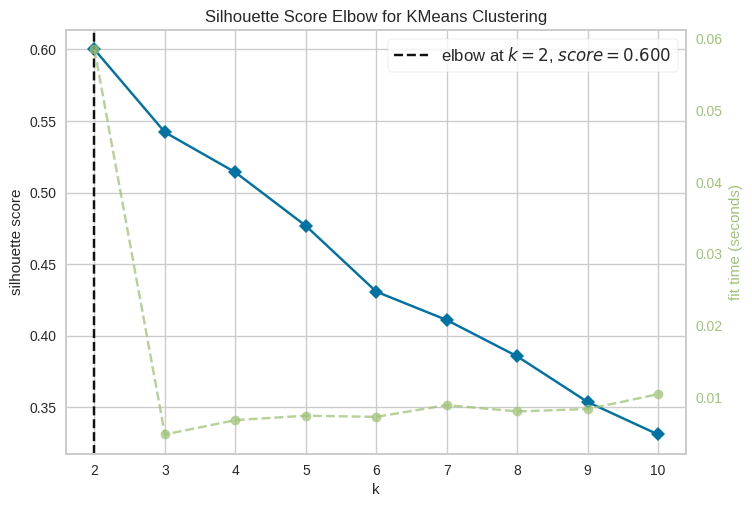

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,11), metric='silhouette')

visualizer.fit(df)
visualizer.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans.fit(df)

labels = kmeans.labels_
centroid = kmeans.cluster_centers_

df['Cluster'] = labels

Jalankan cell code ini untuk menyimpan model kamu.

In [ ]:
import joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [ ]:
silhouette_score(df, labels)

0.6008925146955686

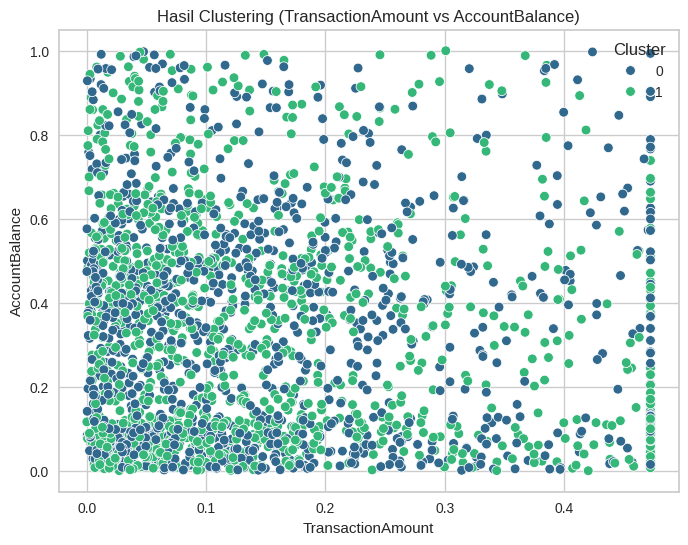

In [ ]:
feature1 = 'TransactionAmount'
feature2 = 'AccountBalance'

plt.figure(figsize=(8, 6))
sns.scatterplot(x=feature1, y=feature2, hue=kmeans.labels_, data=df, palette='viridis')
plt.title(f'Hasil Clustering ({feature1} vs {feature2})')
plt.xlabel(feature1)
plt.ylabel(feature2)

plt.legend(title='Cluster')
plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [ ]:
pca = PCA(n_components=3)
df_scaled = pca.fit_transform(df)

data_final = pd.DataFrame(df_scaled, columns=['PCA1', 'PCA2', 'PCA3'])

kmeans_pca = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_pca.fit(data_final)

pca_labels = kmeans_pca.labels_
pca_centroid = kmeans_pca.cluster_centers_


silhouette_score(data_final, pca_labels)

0.6046450281881771

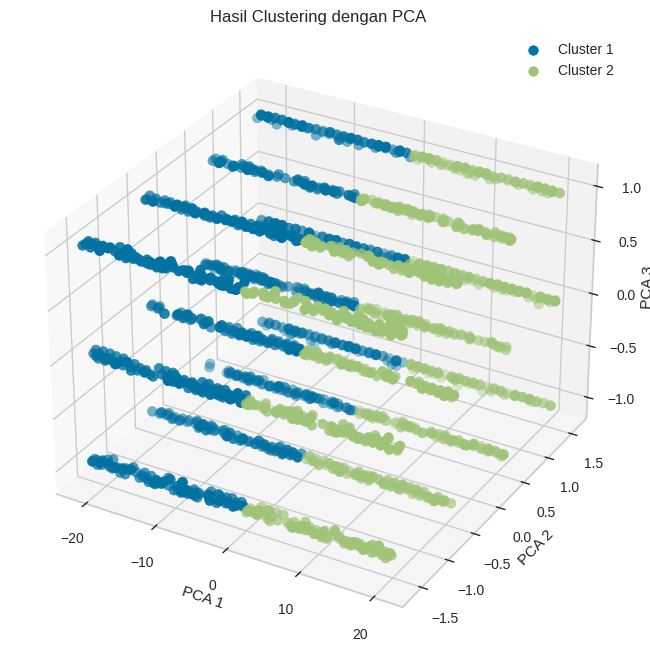

In [ ]:
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")


fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(111, projection='3d')

# unique_labels = np.unique(pca_labels)
for i in range(2):
    cluster_data = data_final[pca_labels == i]
    ax1.scatter(cluster_data['PCA1'], cluster_data['PCA2'], cluster_data['PCA3'], label=f'Cluster {i + 1}', s=50)
ax1.set_xlabel('PCA 1')
ax1.set_ylabel('PCA 2')
ax1.set_zlabel('PCA 3')
plt.title('Hasil Clustering dengan PCA')
plt.legend()
plt.show()

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [ ]:
pd.set_option('display.max_columns', 0)
df.groupby('Cluster').agg(['mean', 'min', 'max', ('modus', lambda x: x.mode()[0])]).T

Cluster                                    0          1
TransactionAmount           mean    0.147791   0.147816
                            min     0.000031   0.000000
                            max     0.472588   0.472588
                            modus   0.472588   0.472588
TransactionType             mean    1.000000   1.000000
                            min     1.000000   1.000000
                            max     1.000000   1.000000
                            modus   1.000000   1.000000
Location                    mean   10.687555  31.913514
                            min     0.000000  22.000000
                            max    21.000000  42.000000
                            modus  13.000000  28.000000
Channel                     mean    0.986761   0.982883
                            min     0.000000   0.000000
                            max     2.000000   2.000000
                            modus   1.000000   1.000000
CustomerAge                 mean    0.285966   0.292793
                            min     0.000000   0.000000
                            max     2.000000   2.000000
                            modus   0.000000   0.000000
CustomerOccupation          mean    1.478376   1.543243
                            min     0.000000   0.000000
                            max     3.000000   3.000000
                            modus   0.000000   3.000000
TransactionDuration         mean    0.384259   0.373473
                            min     0.000000   0.000000
                            max     1.000000   1.000000
                            modus   0.072414   0.182759
LoginAttempts               mean    0.000000   0.000000
                            min     0.000000   0.000000
                            max     0.000000   0.000000
                            modus   0.000000   0.000000
AccountBalance              mean    0.337737   0.334621
                            min     0.001125   0.000064
                            max     0.997633   1.000000
                            modus   0.087303   0.000064
Transaction_Duration_Months mean    0.524860   0.516441
                            min     0.000000   0.000000
                            max     1.000000   1.000000
                            modus   0.416667   0.333333

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 0: (Nasabah dengan Akun Seimbang dan Durasi Transaksi Lebih Lama)**:
- **Rata-rata (mean) AccountBalance: 0.337737**
- **Rata-rata (mean) TransactionAmount: 0.147791**
- **Rata-rata (mean) TransactionDuration: 0.384259**
<Sebelum inverse> <Setelah inverse>
- **Analisis:** Cluster ini mencakup nasabah dengan penyimpanan dana akun yang cukup tinggi serta memiliki durasi transaksi yang lebih lama, namun memiliki jumlah transaksi yang lebih rendah dibandingkan dengan Cluster 1. Nasabah dalam cluster ini cenderung melakukan transaksi dengan jumlah yang lebih kecil namun dengan durasi yang lebih panjang, mengindikasikan transaksi yang mungkin lebih kompleks atau membutuhkan waktu lebih.
- **Rekomendasi:** Tawarkan produk atau layanan yang mendukung transaksi kompleks atau berdurasi panjang, seperti layanan konsultasi keuangan, manajemen aset, atau produk investasi yang membutuhkan analisis mendalam. Berikan dukungan pelanggan yang responsif untuk membantu mereka dalam proses transaksi yang memakan waktu.

2. **Cluster 1: (Nasabah dengan Akun Seimbang dan Durasi Transaksi Lebih Singkat)**:
- **Rata-rata (mean) AccountBalance: 0.334621**
- **Rata-rata (mean) TransactionAmount: 0.147816**
- **Rata-rata (mean) TransactionDuration: 0.373473**
<Sebelum inverse> <Setelah inverse>
- **Analisis:** Cluster ini memiliki rata-rata saldo akun dan jumlah transaksi yang hampir serupa dengan Cluster 0, namun rata-rata durasi transaksinya sedikit lebih pendek dan jumlah transaksi nya sedikit lebih tinggi. Ini bisa mengindikasikan bahwa nasabah di cluster ini melakukan transaksi yang lebih cepat dan efisien dalam jumlah yang cukup tinggi.
- **Rekomendasi:** Fokus pada optimalisasi proses transaksi dan penawaran produk yang mudah diakses dan cepat, seperti aplikasi mobile banking yang efisien, pembayaran digital, atau produk pinjaman instan. Berikan insentif untuk transaksi cepat dan sering dalam nominal tertentu.

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [ ]:
df = df.rename(columns={'Cluster': 'Target'})
df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months,Target
0,0.007207,1,36,0,1,0,0.244828,0.0,0.336832,0.750000,1
1,0.195940,1,15,0,1,0,0.451724,0.0,0.918055,0.500000,0
2,0.065680,1,23,2,0,3,0.158621,0.0,0.068637,0.500000,1
3,0.096016,1,33,2,0,3,0.051724,0.0,0.569198,0.666667,1
5,0.047888,1,28,0,2,3,0.558621,0.0,0.045738,0.750000,1


In [ ]:
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [ ]:
df[numerical_cols] = scaler.inverse_transform(df[numerical_cols])

df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months,Target
0,14.09,1,36,0,1,0,81.0,1.0,5112.21,19.0,1
1,376.24,1,15,0,1,0,141.0,1.0,13758.91,16.0,0
2,126.29,1,23,2,0,3,56.0,1.0,1122.35,16.0,1
3,184.50,1,33,2,0,3,25.0,1.0,8569.06,18.0,1
5,92.15,1,28,0,2,3,172.0,1.0,781.68,19.0,1


In [ ]:
for col in categorical_cols.to_list() + ['CustomerAge']:
    encoder = encoders[col]
    df[col] = encoder.inverse_transform(df[col].astype(int))

df.head(5)

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months,Target
0,14.09,Debit,San Diego,ATM,Lansia,Doctor,81.0,1.0,5112.21,19.0,1
1,376.24,Debit,Houston,ATM,Lansia,Doctor,141.0,1.0,13758.91,16.0,0
2,126.29,Debit,Mesa,Online,Dewasa,Student,56.0,1.0,1122.35,16.0,1
3,184.50,Debit,Raleigh,Online,Dewasa,Student,25.0,1.0,8569.06,18.0,1
5,92.15,Debit,Oklahoma City,ATM,Remaja,Student,172.0,1.0,781.68,19.0,1


In [ ]:
pd.set_option('display.max_columns', 0)

agg_functions = {}
for col in df.columns:
    if np.issubdtype(df[col].dtype, np.number):
       agg_functions[col] = ['mean', 'min', 'max', ('modus', lambda x: x.mode()[0])]
    else:
        agg_functions[col] = [('modus', lambda x: x.mode()[0])]

df.groupby('Target').agg(agg_functions).T

Target                                       0              1
TransactionAmount           mean    283.849241     283.895856
                            min           0.32           0.26
                            max        907.085        907.085
                            modus      907.085        907.085
TransactionType             modus        Debit          Debit
Location                    modus   Fort Worth  Oklahoma City
Channel                     modus       Branch         Branch
CustomerAge                 modus       Dewasa         Dewasa
CustomerOccupation          modus       Doctor        Student
TransactionDuration         mean    121.435128     118.307207
                            min           10.0           10.0
                            max          300.0          300.0
                            modus         31.0           63.0
LoginAttempts               mean           1.0            1.0
                            min            1.0            1.0
                            max            1.0            1.0
                            modus          1.0            1.0
AccountBalance              mean   5125.672692    5079.322486
                            min         117.98          102.2
                            max       14942.78       14977.99
                            modus      1400.04          102.2
Transaction_Duration_Months mean     16.298323      16.197297
                            min           10.0           10.0
                            max           22.0           22.0
                            modus         15.0           14.0
Target                      mean           0.0            1.0
                            min              0              1
                            max              0              1
                            modus            0              1

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 0: ()**:
- **Rata-rata (mean) AccountBalance: 5125.672692**
- **Rata-rata (mean) TransactionAmount: 283.849241**
- **Rata-rata (mean) TransactionDuration: 121.435128**
- **Rata-rata (mean) Transaction_Duration_Months: 16.298323**
- **Nilai Terbanyak (modus) CustomerOccupation: Doctor**
- **Nilai Terbanyak (modus) Location: Fort Worth**
<Sebelum inverse> <Setelah inverse>
- **Analisis:** Cluster ini mencakup nasabah dengan penyimpanan dana akun yang cukup tinggi serta memiliki durasi transaksi yang lebih lama, mayoritas berlokasi di Fort Worth dan berprofesi sebagai Dokter. Namun, dibandingkan dengan Cluster 1, Cluster 0 ini memiliki jumlah transaksi yang sedikit lebih rendah. Nasabah dalam cluster ini cenderung melakukan transaksi dengan jumlah yang lebih kecil namun dengan durasi yang lebih panjang, mengindikasikan transaksi yang mungkin lebih kompleks atau membutuhkan waktu lebih lama.
- **Rekomendasi:** Tawarkan produk atau layanan yang mendukung transaksi kompleks atau berdurasi panjang, seperti layanan konsultasi keuangan, manajemen aset, atau produk investasi yang membutuhkan analisis mendalam. Berikan dukungan pelanggan yang responsif untuk membantu mereka dalam proses transaksi yang memakan waktu.

2. **Cluster 1: ()**:
- **Rata-rata (mean) AccountBalance: 5079.322486**
- **Rata-rata (mean) TransactionAmount: 283.895856**
- **Rata-rata (mean) TransactionDuration: 118.307207**
- **Rata-rata (mean) Transaction_Duration_Months: 16.197297**
- **Nilai Terbanyak (modus) CustomerOccupation: Student**
- **Nilai Terbanyak (modus) Location: Oklahoma City**
<Sebelum inverse> <Setelah inverse>
- **Analisis:** Cluster ini memiliki rata-rata saldo akun dan jumlah transaksi yang hampir serupa dengan Cluster 0, namun rata-rata durasi transaksinya sedikit lebih pendek dan jumlah transaksi nya sedikit lebih tinggi, mayoritas berlokasi di Oklahoma City dan merupakan seorang pelajar. Ini bisa mengindikasikan bahwa nasabah di cluster ini melakukan transaksi yang lebih cepat dan efisien dalam jumlah yang cukup tinggi.
- **Rekomendasi:** Fokus pada optimalisasi proses transaksi dan penawaran produk yang mudah diakses dan cepat, seperti aplikasi mobile banking yang efisien, pembayaran digital, atau produk pinjaman instan. Berikan insentif untuk transaksi cepat dan sering dalam nominal tertentu.

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [ ]:
df

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Transaction_Duration_Months,Target
0,14.09,Debit,San Diego,ATM,Lansia,Doctor,81.0,1.0,5112.21,19.0,1
1,376.24,Debit,Houston,ATM,Lansia,Doctor,141.0,1.0,13758.91,16.0,0
2,126.29,Debit,Mesa,Online,Dewasa,Student,56.0,1.0,1122.35,16.0,1
3,184.50,Debit,Raleigh,Online,Dewasa,Student,25.0,1.0,8569.06,18.0,1
5,92.15,Debit,Oklahoma City,ATM,Remaja,Student,172.0,1.0,781.68,19.0,1
...,...,...,...,...,...,...,...,...,...,...,...
2510,185.97,Debit,Denver,Online,Dewasa,Student,19.0,1.0,1776.91,21.0,0
2511,243.08,Debit,Jacksonville,Online,Dewasa,Student,93.0,1.0,131.25,21.0,0
2523,12.18,Debit,New York,Branch,Lansia,Retired,77.0,1.0,4909.24,19.0,1
2524,232.12,Debit,Omaha,ATM,Dewasa,Engineer,51.0,1.0,6689.87,10.0,1


In [ ]:
df.to_csv('data_clustering_inverse.csv', index=False)

End of Code.